<a href="https://colab.research.google.com/github/un1u3/ml-labs/blob/main/Deep%20Learning/Pytorch/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [60]:
torch.manual_seed(42)

In [61]:
df = pd.read_csv('fashion-mnist_test.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [62]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


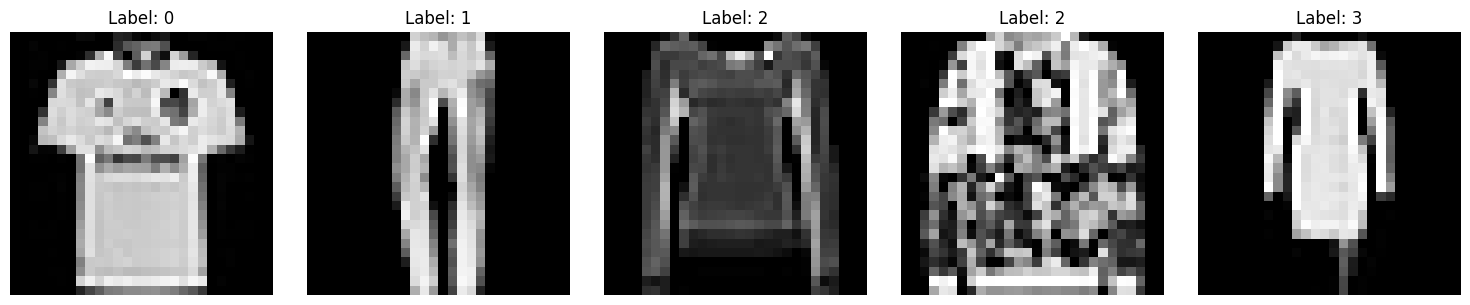

In [63]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots arranged in 1 row and 5 columns.
# Adjust figsize as needed to fit the images well.
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

# Loop through the first 5 rows of the DataFrame to visualize multiple images.
for i in range(5):
    # Select the current row of the DataFrame.
    image_data = df.iloc[i]

    # The first column is the 'label', so we exclude it to get only pixel data.
    pixel_values = image_data[1:].values

    # Reshape the 784 pixel values into a 28x28 array.
    image = pixel_values.reshape(28, 28)

    # Display the image on the current subplot.
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Label: {image_data['label']}") # Add a title with the image's label
    axes[i].axis('off') # Hide the axes for a cleaner image display

plt.tight_layout() # Adjust layout to prevent titles/labels from overlapping
plt.show()

In [64]:
X = df.iloc[:, 1:].values # Corrected to include all pixel columns
y = df.iloc[:, 0].values

In [65]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [66]:
# scaling the features
X_train = X_train/255.0
X_test = X_test/255.0

In [67]:
# create CustomDataset class
class CustomDataset(Dataset):

  def __init__(self, features, labels):
    super().__init__() # Corrected line
    self.features = torch.tensor(features, dtype = torch.float32)
    self.labels = torch.tensor(labels, dtype = torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [68]:
# create train_dataset
train_dataset = CustomDataset(X_train, y_train)

In [69]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [70]:
test_dataset = CustomDataset(X_test, y_test)

In [71]:
# create train and test loader
train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle = True
)

In [72]:
class MyNN(nn.Module):
  def __init__(self,num_features, num_classes=10):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(64, num_classes)

    )


  def forward(self, x):
    return self.model(x)

In [73]:
epochs = 100
learning_rate = 0.1


In [74]:
# instintiate the model
model = MyNN(X_train.shape[1])

# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.SGD(model.parameters(),lr = learning_rate, weight_decay=0.001)

In [75]:
# Training loop
epochs = 100 # Using the previously defined epochs variable

# Lists to store loss for plotting
loss_history = []

for epoch in range(epochs):
  current_loss = 0.0
  for batch_features, batch_labels in train_loader:
    # Forward pass
    outputs = model(batch_features)

    # Calculate loss
    loss = criterion(outputs, batch_labels)
    current_loss += loss.item()

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  # Print loss every 10 epochs
  if (epoch + 1) % 10 == 0:
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {current_loss/len(train_loader):.4f}')
  loss_history.append(current_loss/len(train_loader))

print('Training finished.')

Epoch [10/100], Loss: 0.4162
Epoch [20/100], Loss: 0.3443
Epoch [30/100], Loss: 0.3022
Epoch [40/100], Loss: 0.2711
Epoch [50/100], Loss: 0.2694
Epoch [60/100], Loss: 0.2717
Epoch [70/100], Loss: 0.2535
Epoch [80/100], Loss: 0.2477
Epoch [90/100], Loss: 0.2354
Epoch [100/100], Loss: 0.2314
Training finished.


In [76]:
# set model to eval mode
model.eval()


MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [77]:
total = 0
correct = 0

with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    outputs = model(batch_features)
    _, predicted = torch.max(outputs, 1)
    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item() # Fix: sum() and item() to keep 'correct' a scalar

  print(correct/total)

0.8445
